<a href="https://colab.research.google.com/github/HamzaEric/gan-dcgan-art-generation/blob/main/Notebooks/Latent_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Purpose Of The Notebook**

This notebook bridges the gap between *evaluation* and *creative expression*.  
Instead of optimizing losses or training new models, we will **use a pretrained DCGAN** to explore how its **latent space** (the space of random input vectors) captures artistic variation and creativity.

We will:

- **Use the pretrained DCGAN generator** to synthesize new artworks directly from noise vectors.  
- **Explore the latent space** to understand how small changes in the noise input ($z$) can produce smooth or dramatic changes in visual style.  
- **Blend and interpolate styles** by moving between two points in latent space, effectively creating hybrid or transitional artworks.  
- **Reflect on creative and ethical aspects** — how AI challenges our understanding of creativity, authorship, and originality.

In [5]:
import torch
import torch.nn as nn
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import torchvision

device = torch.device("cpu")
print("Device in use:", device)

Device in use: cpu


**Generator Architecture**

In [2]:
class GeneratorDCGAN(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, feature_maps=64):
        super().__init__()
        self.net = nn.Sequential(
            # (N, z_dim, 1, 1) -> (N, feature_maps*4, 4, 4)
            nn.ConvTranspose2d(z_dim, feature_maps*4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feature_maps*4),
            nn.ReLU(True),

            # 4x4 -> 8x8
            nn.ConvTranspose2d(feature_maps*4, feature_maps*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps*2),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(feature_maps*2, feature_maps, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(feature_maps, feature_maps//2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps//2),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(feature_maps//2, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)

In [3]:
# === Load pretrained generator
G_pretrained = GeneratorDCGAN(z_dim=100, img_channels=3, feature_maps=64).to(device)
state = torch.load("/content/G_dcgan_epoch_200.pth", map_location=device)
G_pretrained.load_state_dict(state, strict=True)
G_pretrained.eval()
print("Pretrained DCGAN Generator loaded successfully (feature_maps=64, self.net).")

Pretrained DCGAN Generator loaded successfully (feature_maps=64, self.net).


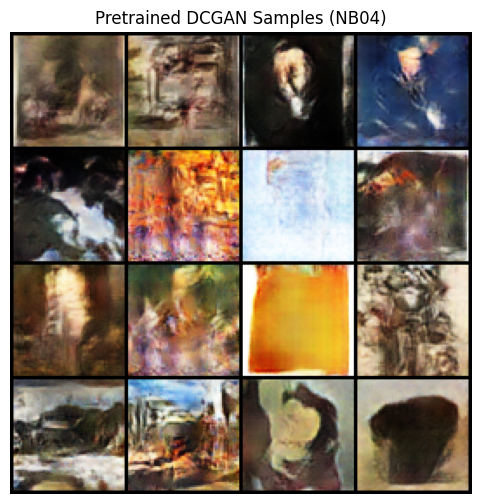

In [4]:
with torch.no_grad():
    z = torch.randn(16, 100, 1, 1, device=device)
    fake = G_pretrained(z).cpu()

grid = make_grid((fake + 1) / 2, nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Pretrained DCGAN Samples (NB04)")
plt.show()

#### **Exploring Diversity in Latent Space**

In a GAN, the latent vector $z \sim \mathcal{N}(0, I)$ acts like a **creative code**.  
If our generator has learned a meaningful representation, then **small, smooth changes** in $z$ should produce **small, smooth changes** in the output image (color palette, textures, composition). Here, we will:

1. **Fix most dimensions of $z$** and vary only a **couple of coordinates**, to see targeted changes.  
2. Create a **2D traversal grid** around a base latent vector to visualize local diversity.  
3. Reflect on whether changes are **smooth** (good sign) or **chaotic/jumpy** (poorly structured latent space).

We will use our **pretrained DCGAN** so that the latent space is already well-formed.

In [6]:
assert 'G_pretrained' in globals(), "Please run Section 2 to load `G_pretrained`."
G_eval = G_pretrained.eval()
device = next(G_eval.parameters()).device

latent_dim = 100

def denorm(x):
    return (x + 1) / 2

@torch.no_grad()
def decode_latents(Z):
    """
    Z: (N, latent_dim, 1, 1)
    Returns: images tensor in [-1, 1]
    """
    return G_eval(Z).cpu()

def show_grid(imgs, nrow, title):
    grid = torchvision.utils.make_grid(denorm(imgs).clamp(0,1), nrow=nrow, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(title)
    plt.show()

**1D Traversal**

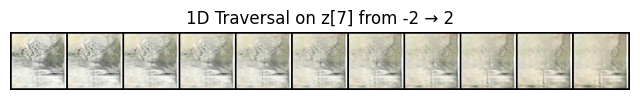

In [7]:
z0 = torch.randn(1, latent_dim, 1, 1, device=device)

k = 7                         # which dimension to vary
values = torch.linspace(-2.0, 2.0, steps=11).to(device)

Z = []
for v in values:
    z = z0.clone()
    z[:, k, :, :] = v
    Z.append(z)
Z = torch.cat(Z, dim=0)       # (11, latent_dim, 1, 1)

imgs_1d = decode_latents(Z)
show_grid(imgs_1d, nrow=11, title=f"1D Traversal on z[{k}] from -2 → 2")

**2D Traversal**

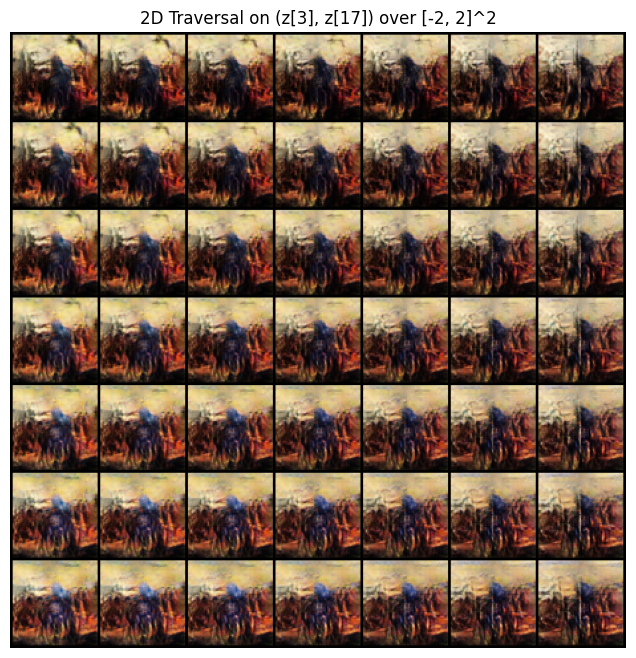

In [8]:
z0 = torch.randn(1, latent_dim, 1, 1, device=device)

i, j = 3, 17                     # two latent dimensions to sweep
grid_lin = torch.linspace(-2.0, 2.0, steps=7).to(device)  # 7x7 grid

Z_list = []
for a in grid_lin:               # vertical axis (row)
    for b in grid_lin:           # horizontal axis (col)
        z = z0.clone()
        z[:, i, :, :] = a
        z[:, j, :, :] = b
        Z_list.append(z)

Z_grid = torch.cat(Z_list, dim=0)  # (49, latent_dim, 1, 1)
imgs_2d = decode_latents(Z_grid)
show_grid(imgs_2d, nrow=len(grid_lin), title=f"2D Traversal on (z[{i}], z[{j}]) over [-2, 2]^2")

**Partial-Fix Traversal (vary several dims, keep a semantic “core”)**

Sometimes it helps to **stabilize a small subset** of coordinates (e.g., those that seem to control composition) and let a few others vary to see **texture or palette** changes. We can randomly choose a handful of indices to vary while keeping the rest fixed.


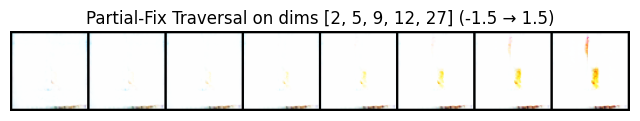

In [9]:
z0 = torch.randn(1, latent_dim, 1, 1, device=device)

vary_idx = torch.tensor([2, 5, 9, 12, 27], device=device)  # a few coords to vary
steps = 8
alphas = torch.linspace(-1.5, 1.5, steps=steps).to(device)

Z_list = []
for a in alphas:
    z = z0.clone()
    z[:, vary_idx, :, :] = a
    Z_list.append(z)
Z_line = torch.cat(Z_list, dim=0)  # (steps, latent_dim, 1, 1)

imgs_partial = decode_latents(Z_line)
show_grid(imgs_partial, nrow=steps, title=f"Partial-Fix Traversal on dims {vary_idx.tolist()} (-1.5 → 1.5)")

#### **Latent Interpolation (Between Two Paintings)**

A compelling way to explore a GAN’s **creative latent space** is through **interpolation** between two latent codes.  
If the latent manifold is **smooth and coherent**, linearly blending between two random points in $ z $-space should produce a **gradual morph** between two distinct artistic “styles” — showing evolving **color palettes**, **textures**, and **composition**.

**What we’ll do**

- Sample two random latent vectors $ z_1 $ and $ z_2 $.  
- Interpolate between them using 10 evenly spaced coefficients:
  $$
  z_\alpha = (1-\alpha)\,z_1 + \alpha\,z_2,\quad \alpha \in \left\{0,\tfrac{1}{9},\tfrac{2}{9},\dots,1\right\}.
  $$
- Decode each $ z_\alpha $ using our pretrained generator $ G $.
- Visualize the 10 generated images in a **horizontal gallery**.

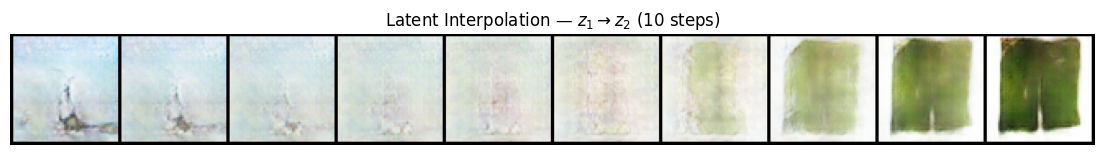

In [10]:
assert 'G_pretrained' in globals(), "Please run Section 3 to load pretrained generator as 'G_pretrained'."
G_pretrained.eval()
device = next(G_pretrained.parameters()).device

# --- Linear interpolation function ---
@torch.no_grad()
def interpolate_linearly(z1, z2, steps=10):
    """
    Linear interpolation between z1 and z2 in latent space.
    z1, z2: tensors of shape (1, z_dim, 1, 1)
    returns: tensor of shape (steps, z_dim, 1, 1)
    """
    alphas = torch.linspace(0.0, 1.0, steps, device=z1.device)
    Z = [(1 - a) * z1 + a * z2 for a in alphas]
    return torch.cat(Z, dim=0)

# --- Sample latent endpoints ---
torch.manual_seed(42)
z_dim = 100
z1 = torch.randn(1, z_dim, 1, 1, device=device)
z2 = torch.randn(1, z_dim, 1, 1, device=device)

# --- Generate interpolation sequence ---
Z_line = interpolate_linearly(z1, z2, steps=10)
with torch.no_grad():
    imgs = G_pretrained(Z_line).cpu()
imgs = (imgs + 1) / 2  # denormalize to [0,1]

# --- Plot horizontal gallery ---
grid = make_grid(imgs, nrow=10, padding=2)
plt.figure(figsize=(14, 2.2))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Latent Interpolation — $z_1 \\rightarrow z_2$ (10 steps)")
plt.show()

#### **Style Blending and Latent Semantics**

In this optional experiment, we explore **style blending** — mixing two different latent codes to create a *hybrid* painting that visually combines artistic traits from both.

We treat the **latent vector $ z $** as an internal “DNA” of the generated artwork:
- Some dimensions may influence **color palette** (e.g., warm vs. cool tones).  
- Others may affect **composition** or **texture** (e.g., abstract vs. structured strokes).  

By merging parts of two latent codes, we can observe how GANs internally organize **visual semantics** — whether attributes like color and texture are **disentangled** (independent) or **entangled** (interacting).

**Plan**

1. Sample two latent vectors, $ z_A $ and $ z_B $.  
2. Construct a *hybrid* vector:
   $$
   z_{\text{mix}} = [\,z_A^{(0:50)},\, z_B^{(50:100)}\,]
   $$
   i.e., first 50 dimensions from $ z_A $ and last 50 from $ z_B $.  
3. Decode $ z_A $, $ z_B $, and $ z_{\text{mix}} $ using the pretrained generator.

**Interpretation**

- If the hybrid painting exhibits **blended features** (e.g., *colors from A, structure from B*), it suggests that the generator’s latent space contains **disentangled, interpretable factors**.  
- If the mix appears random or unstable, it indicates **entanglement** — visual attributes interact in nonlinear ways, typical of early GANs.

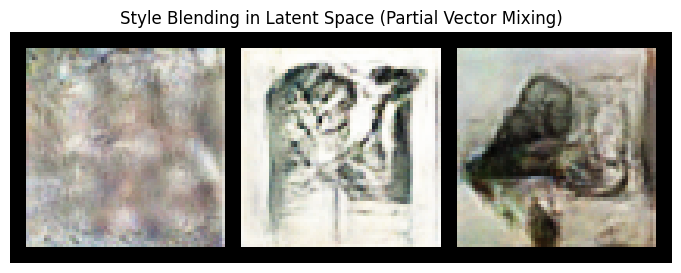

In [15]:
G_pretrained.eval()
device = next(G_pretrained.parameters()).device
z_dim = 100

@torch.no_grad()
def blend_latent_styles(zA, zB, split_index=50):
    """
    Create a hybrid latent vector by combining the first part of zA and the rest of zB.
    """
    return torch.cat([zA[:, :split_index, :, :], zB[:, split_index:, :, :]], dim=1)


zA = torch.randn(1, z_dim, 1, 1, device=device)
zB = torch.randn(1, z_dim, 1, 1, device=device)
z_mix = blend_latent_styles(zA, zB, split_index=50)

# --- Generate the three paintings ---
with torch.no_grad():
    imgs = G_pretrained(torch.cat([zA, z_mix, zB], dim=0)).cpu()

# --- Normalize and display ---
imgs = (imgs + 1) / 2
titles = ["Style A", "Mixed (A+B)", "Style B"]

grid = make_grid(imgs, nrow=3, padding=5)
plt.figure(figsize=(9, 3))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Style Blending in Latent Space (Partial Vector Mixing)")
plt.show()
